# 01_data — PocketBirdNET Dataset Pipeline

**Run once.**  This notebook queries Xeno-Canto, downloads recordings, extracts
log-mel spectrograms, splits at the recording level, and caches everything to disk.
All downstream notebooks read the cache and never touch raw audio.

**Stage order:**
1. Config & imports
2. Species configuration and class list
3. Xeno-Canto query — build the recording manifest
4. Download → window → mel-spec → delete (process-and-delete)
5. Recording-level split (70 / 15 / 15)
6. Augmentation (train split only)
7. Save `data/{train,val,test}.npz` and `data/metadata.csv`
8. Sanity report + example spectrogram plots

**Idempotency:** each stage checks for its own output file before running.
Re-executing the notebook resumes from the last incomplete stage.

**Hard constraints honoured (CLAUDE.md):**
- `audio_to_logmel` is called exclusively from `utils.py` — single source of truth.
- Splits are keyed on `recording_id`, never on window index.
- Raw mp3 files are deleted immediately after processing.
- API key is never hardcoded — read from `os.environ['XENO_CANTO_API_KEY']`.

## §1  Config & imports

In [1]:
import os, sys, json, time, shutil, pathlib, logging, warnings
import numpy as np
import pandas as pd
import requests
import soundfile as sf
import librosa
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm

# ── Locate repo root (works in both Jupyter and script contexts) ──────────────
try:
    _here = pathlib.Path(__file__).resolve().parent   # script
except NameError:
    _here = pathlib.Path.cwd()                        # Jupyter: assume cwd = notebooks/

REPO_ROOT = _here.parent if _here.name == "notebooks" else _here
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from utils import audio_to_logmel, recording_level_split, SAMPLE_RATE, WINDOW_SAMPLES

warnings.filterwarnings("ignore", category=UserWarning)
logging.basicConfig(level=logging.INFO, format="%(asctime)s %(levelname)s %(message)s")
log = logging.getLogger("01_data")

# ── API auth ──────────────────────────────────────────────────────────────────
XC_API_KEY = os.environ.get("XENO_CANTO_API_KEY", "")
if not XC_API_KEY:
    raise EnvironmentError(
        "\n"
        "  Missing Xeno-Canto API key.\n"
        "  Set it before starting the kernel:\n"
        "    export XENO_CANTO_API_KEY=<your_key>\n"
        "  then restart the kernel and re-run."
    )

# ── Paths ─────────────────────────────────────────────────────────────────────
DATA_DIR      = REPO_ROOT / "data"
DATA_DIR.mkdir(exist_ok=True)
(DATA_DIR / "_tmp_audio").mkdir(exist_ok=True)

QUERY_LOG_F   = DATA_DIR / "query_log.json"
MANIFEST_F    = DATA_DIR / "manifest.csv"        # one row per recording
WINDOWS_NPZ_F = DATA_DIR / "windows_raw.npz"     # stacked spectrograms, no split
WIN_META_F    = DATA_DIR / "windows_meta.csv"    # per-window metadata, no split
TRAIN_NPZ_F   = DATA_DIR / "train.npz"
VAL_NPZ_F     = DATA_DIR / "val.npz"
TEST_NPZ_F    = DATA_DIR / "test.npz"
META_CSV_F    = DATA_DIR / "metadata.csv"        # per-window metadata WITH split column
TMP_DIR       = DATA_DIR / "_tmp_audio"
PROGRESS_F    = DATA_DIR / "_progress.json"

print(f"Repo root : {REPO_ROOT}")
print(f"Data dir  : {DATA_DIR}")
print(f"API key   : set (length={len(XC_API_KEY)})")

Repo root : /Users/aaravwadhwani/Desktop/EE446/Final Project/PocketBirdNET
Data dir  : /Users/aaravwadhwani/Desktop/EE446/Final Project/PocketBirdNET/data
API key   : set (length=40)


## §2  Species configuration

11 classes: 10 Pacific Northwest species + background.  **Order is fixed** — integer
label = list index.  Do not reorder without regenerating all `.npz` caches.

In [2]:
# Class list — integer label = index in this list.  FIXED.
SPECIES = [
    "American Robin",          # 0
    "Black-capped Chickadee",  # 1
    "Steller's Jay",           # 2
    "Northern Flicker",        # 3
    "Song Sparrow",            # 4
    "Anna's Hummingbird",      # 5
    "Dark-eyed Junco",         # 6
    "American Crow",           # 7
    "Pacific Wren",            # 8
    "House Finch",             # 9
    "background",              # 10
]
LABEL_MAP = {name: idx for idx, name in enumerate(SPECIES)}
N_CLASSES = len(SPECIES)

# Per-class data targets (from PROJECT_PLAN.md §4)
TARGET_WINDOWS_PER_CLASS  = 8000  # ~400 min at 3 s/window; 400 recs × ~20 avg wins
MIN_RECORDINGS_PER_CLASS  = 20    # so the 15% test slice >= 3 recordings
MAX_RECORDINGS_PER_CLASS  = 400   # hard cap per class
MAX_WINDOWS_PER_RECORDING = 30    # raised from 15 so longer recordings contribute more

# Xeno-Canto v3 base URL and query params
XC_BASE = "https://xeno-canto.org/api/3/recordings"
XC_LEN  = "len:10-120"

# Scientific names used in XC queries (common names often fail)
SPECIES_XC_QUERY = {
    "American Robin":          "Turdus migratorius",
    "Black-capped Chickadee":  "Poecile atricapillus",
    "Steller's Jay":           "Cyanocitta stelleri",
    "Northern Flicker":        "Colaptes auratus",
    "Song Sparrow":            "Melospiza melodia",
    "Anna's Hummingbird":      "Calypte anna",
    "Dark-eyed Junco":         "Junco hyemalis",
    "American Crow":           "Corvus brachyrhynchos",
    "Pacific Wren":            "Troglodytes pacificus",
    "House Finch":             "Haemorhous mexicanus",
}

print(f"{N_CLASSES} classes: {SPECIES}")

11 classes: ['American Robin', 'Black-capped Chickadee', "Steller's Jay", 'Northern Flicker', 'Song Sparrow', "Anna's Hummingbird", 'Dark-eyed Junco', 'American Crow', 'Pacific Wren', 'House Finch', 'background']


## §3  Stage 1 — Build the recording manifest

Query Xeno-Canto with quality A then B, paginating until `MAX_RECORDINGS_PER_CLASS`
recordings are found.  Background uses ambient/soundscape recordings.

Saves `data/query_log.json` and `data/manifest.csv`.

**Idempotent** — skips if `manifest.csv` already exists.

In [3]:
def xc_search(query: str, max_n: int) -> list:
    """Query XC v3 with pagination. Returns up to max_n recording dicts."""
    results = []
    page = 1
    while len(results) < max_n:
        params = {"query": query, "key": XC_API_KEY, "page": page}
        resp = requests.get(XC_BASE, params=params, timeout=30)
        resp.raise_for_status()
        data = resp.json()
        batch = data.get("recordings", [])
        results.extend(batch)
        total_pages = int(data.get("numPages", 1))
        log.info("  XC page %d/%d — batch=%d cumulative=%d",
                 page, total_pages, len(batch), len(results))
        if page >= total_pages or not batch:
            break
        page += 1
        time.sleep(1.5)   # polite pacing
    return results[:max_n]


def parse_duration(length_str) -> float:
    """Parse XC duration strings ('0:40', '1:23', '1:02:30') to seconds."""
    if not length_str:
        return 0.0
    try:
        return float(length_str)
    except (ValueError, TypeError):
        pass
    try:
        parts = [float(p) for p in str(length_str).strip().split(":")]
        if len(parts) == 2:
            return parts[0] * 60 + parts[1]
        if len(parts) == 3:
            return parts[0] * 3600 + parts[1] * 60 + parts[2]
    except Exception:
        pass
    return 0.0


def rec_to_row(rec: dict, species: str) -> dict:
    return {
        "recording_id": str(rec["id"]),
        "species":      species,
        "file_url":     rec.get("file", ""),
        "duration_s":   parse_duration(rec.get("length", 0)),
        "quality":      rec.get("q", ""),
        "country":      rec.get("cnt", ""),
    }


# XC v3 requires tag-only queries.  Species must use sp:"<name>" (quoted).
# Free text like "Turdus migratorius" returns 400 Bad Request.
def make_species_query(sci_name: str, quality: str) -> str:
    return f'sp:"{sci_name}" {quality} {XC_LEN}'


if MANIFEST_F.exists():
    # Re-use cache only if it has actual rows (guard against the empty-manifest case)
    _tmp = pd.read_csv(MANIFEST_F, dtype=str)
    if len(_tmp) > 0:
        log.info("manifest.csv exists (%d rows) — skipping query stage.", len(_tmp))
        manifest_df = _tmp
    else:
        log.warning("manifest.csv exists but is empty — re-querying.")
        MANIFEST_F.unlink()

if not MANIFEST_F.exists():
    query_log = {}
    all_rows = []

    # Bird species — sp:"<scientific name>" tag syntax
    for species, sci_name in SPECIES_XC_QUERY.items():
        log.info("Querying: %s", species)
        rows = []
        for quality in ["q:A", "q:B"]:
            needed = MAX_RECORDINGS_PER_CLASS - len(rows)
            if needed <= 0:
                break
            q = make_species_query(sci_name, quality)
            try:
                recs = xc_search(q, max_n=needed)
                rows.extend([rec_to_row(r, species) for r in recs])
                query_log.setdefault(species, []).append({"query": q, "returned": len(recs)})
            except Exception as exc:
                log.warning("  query failed: %s", exc)
            time.sleep(2.0)
        log.info("  → %d recordings", len(rows))
        all_rows.extend(rows[:MAX_RECORDINGS_PER_CLASS])

    # Background class — soundscape tag works fine without sp:
    log.info("Querying: background")
    bg_rows = []
    for q in [f"type:soundscape {XC_LEN} q:A",
               f"type:soundscape {XC_LEN} q:B"]:
        needed = MAX_RECORDINGS_PER_CLASS - len(bg_rows)
        if needed <= 0:
            break
        try:
            recs = xc_search(q, max_n=needed)
            bg_rows.extend([rec_to_row(r, "background") for r in recs])
            query_log.setdefault("background", []).append({"query": q, "returned": len(recs)})
        except Exception as exc:
            log.warning("  bg query failed: %s", exc)
        time.sleep(2.0)
    log.info("  → %d background recordings", len(bg_rows))
    all_rows.extend(bg_rows[:MAX_RECORDINGS_PER_CLASS])

    QUERY_LOG_F.write_text(json.dumps(query_log, indent=2))
    manifest_df = pd.DataFrame(all_rows)
    manifest_df.to_csv(MANIFEST_F, index=False)
    log.info("Saved manifest: %d total recordings", len(manifest_df))

print("Recordings per species:")
if len(manifest_df) > 0:
    print(manifest_df.groupby("species")["recording_id"].count().to_string())
else:
    print("  WARNING: manifest is empty — check API key and query format.")

2026-06-03 02:01:27,463 INFO Querying: American Robin
2026-06-03 02:01:28,723 INFO   XC page 1/3 — batch=100 cumulative=100
2026-06-03 02:01:31,488 INFO   XC page 2/3 — batch=100 cumulative=200
2026-06-03 02:01:34,042 INFO   XC page 3/3 — batch=54 cumulative=254
2026-06-03 02:01:37,629 INFO   XC page 1/3 — batch=100 cumulative=100
2026-06-03 02:01:40,293 INFO   XC page 2/3 — batch=100 cumulative=200
2026-06-03 02:01:43,807 INFO   → 400 recordings
2026-06-03 02:01:43,808 INFO Querying: Black-capped Chickadee
2026-06-03 02:01:45,001 INFO   XC page 1/2 — batch=100 cumulative=100
2026-06-03 02:01:47,156 INFO   XC page 2/2 — batch=2 cumulative=102
2026-06-03 02:01:50,536 INFO   XC page 1/3 — batch=100 cumulative=100
2026-06-03 02:01:53,196 INFO   XC page 2/3 — batch=100 cumulative=200
2026-06-03 02:01:55,401 INFO   XC page 3/3 — batch=0 cumulative=200
2026-06-03 02:01:57,405 INFO   → 302 recordings
2026-06-03 02:01:57,405 INFO Querying: Steller's Jay
2026-06-03 02:01:58,526 INFO   XC page 1

Recordings per species:
species
American Crow             334
American Robin            400
Anna's Hummingbird        179
Black-capped Chickadee    302
Dark-eyed Junco           400
House Finch               362
Northern Flicker          284
Pacific Wren              229
Song Sparrow              400
Steller's Jay             256
background                400


## §4  Stage 2 — Download → window → mel-spec → delete

For each recording:
1. Download mp3 to `data/_tmp_audio/<id>.mp3`
2. Decode + resample to 16 kHz mono
3. Cut 3-second windows at 50% overlap
4. Cap at `MAX_WINDOWS_PER_RECORDING`
5. Call `audio_to_logmel` (from `utils.py`) on each window
6. **Delete the mp3 immediately** — raw audio is never retained
7. Record per-window metadata

Progress is saved after each recording (`data/_progress.json`) so the cell
can be interrupted and resumed.  Writes `data/windows_raw.npz` and
`data/windows_meta.csv` at the end.

**Idempotent** — skips if both output files already exist.

In [4]:
def download_audio(file_url: str, dest: pathlib.Path, rid: str) -> bool:
    """Download a single XC mp3. Returns True on success."""
    try:
        params = {"key": XC_API_KEY} if "xeno-canto.org" in file_url else {}
        r = requests.get(file_url, params=params, timeout=60, stream=True)
        r.raise_for_status()
        with open(dest, "wb") as fh:
            for chunk in r.iter_content(65536):
                fh.write(chunk)
        return True
    except Exception as exc:
        log.warning("Download failed for %s: %s", rid, exc)
        return False


def process_recording(file_url: str, rid: str, species: str) -> tuple:
    """Download, window, and mel-spec one recording.  Deletes audio immediately.

    Returns
    -------
    specs : list of (40, 32, 1) float32 arrays
    meta  : list of dicts with recording_id, species, window_idx, source_url
    """
    tmp = TMP_DIR / f"{rid}.mp3"
    specs, meta = [], []
    try:
        if not download_audio(file_url, tmp, rid):
            return [], []
        try:
            samples, _ = librosa.load(str(tmp), sr=SAMPLE_RATE, mono=True)
        except Exception as exc:
            log.warning("librosa.load failed for %s: %s", rid, exc)
            return [], []

        hop = WINDOW_SAMPLES // 2   # 50% overlap
        start = 0
        win_idx = 0
        while start + WINDOW_SAMPLES <= len(samples) and win_idx < MAX_WINDOWS_PER_RECORDING:
            window = samples[start : start + WINDOW_SAMPLES]
            specs.append(audio_to_logmel(window, sr=SAMPLE_RATE))
            meta.append({
                "recording_id": rid,
                "species":      species,
                "window_idx":   str(win_idx),
                "source_url":   file_url,
            })
            start   += hop
            win_idx += 1
    finally:
        if tmp.exists():
            tmp.unlink()   # always delete — never retain raw audio
    return specs, meta


# ── Run (or skip) ─────────────────────────────────────────────────────────────
if WINDOWS_NPZ_F.exists() and WIN_META_F.exists():
    log.info("windows_raw.npz + windows_meta.csv found — loading cache.")
    _raw      = np.load(WINDOWS_NPZ_F)
    all_specs = list(_raw["specs"])
    win_meta_df = pd.read_csv(WIN_META_F, dtype=str)
    all_meta    = win_meta_df.to_dict("records")
else:
    done_ids: set = set()
    all_specs: list = []
    all_meta:  list = []

    if PROGRESS_F.exists():
        _prog = json.loads(PROGRESS_F.read_text())
        done_ids = set(_prog.get("done_ids", []))
        log.info("Resuming: %d recordings already processed.", len(done_ids))

    todo = manifest_df[~manifest_df["recording_id"].isin(done_ids)]
    log.info("%d recordings to process.", len(todo))

    for _, row in tqdm(todo.iterrows(), total=len(todo), desc="Processing recordings"):
        rid     = str(row["recording_id"])
        species = str(row["species"])
        url     = str(row.get("file_url", ""))

        if not url or url == "nan":
            log.warning("No file URL for %s — skipping.", rid)
            done_ids.add(rid)
            continue

        s, m = process_recording(url, rid, species)
        if s:
            all_specs.extend(s)
            all_meta.extend(m)
            log.info("  %s (%s): %d windows", rid, species, len(s))
        else:
            log.warning("  %s: 0 windows extracted.", rid)

        done_ids.add(rid)
        PROGRESS_F.write_text(json.dumps({"done_ids": list(done_ids)}))
        time.sleep(0.5)

    specs_arr = np.stack(all_specs, axis=0).astype(np.float32)
    win_meta_df = pd.DataFrame(all_meta)
    np.savez_compressed(WINDOWS_NPZ_F, specs=specs_arr)
    win_meta_df.to_csv(WIN_META_F, index=False)
    log.info("Saved %d windows to %s", len(all_specs), WINDOWS_NPZ_F)

print(f"Total windows in cache: {len(all_specs)}")
if all_meta:
    _tmp_df = pd.DataFrame(all_meta)
    print(_tmp_df.groupby("species")["recording_id"].count().rename("windows").to_string())

2026-06-03 02:03:46,509 INFO 3546 recordings to process.


Processing recordings:   0%|          | 0/3546 [00:00<?, ?it/s]

2026-06-03 02:03:51,081 INFO   1139951 (American Robin): 10 windows
2026-06-03 02:03:54,439 INFO   1139498 (American Robin): 30 windows
2026-06-03 02:03:56,563 INFO   1138978 (American Robin): 11 windows
2026-06-03 02:03:59,221 INFO   1135112 (American Robin): 16 windows
2026-06-03 02:04:02,551 INFO   1107061 (American Robin): 30 windows
2026-06-03 02:04:08,105 INFO   1100538 (American Robin): 30 windows
2026-06-03 02:04:14,646 INFO   1099293 (American Robin): 27 windows
2026-06-03 02:04:16,860 INFO   1089129 (American Robin): 9 windows
2026-06-03 02:04:18,929 INFO   1079586 (American Robin): 26 windows
2026-06-03 02:04:21,530 INFO   1068477 (American Robin): 30 windows
2026-06-03 02:04:23,911 INFO   1047670 (American Robin): 29 windows
2026-06-03 02:04:28,379 INFO   1023050 (American Robin): 30 windows
2026-06-03 02:04:31,501 INFO   1010651 (American Robin): 21 windows
2026-06-03 02:04:34,013 INFO   1005778 (American Robin): 30 windows
2026-06-03 02:04:35,854 INFO   999808 (American R

Total windows in cache: 75027
species
American Crow             6299
American Robin            9209
Anna's Hummingbird        3269
Black-capped Chickadee    6712
Dark-eyed Junco           8737
House Finch               7989
Northern Flicker          5871
Pacific Wren              4960
Song Sparrow              9019
Steller's Jay             5073
background                7889


## §5  Stage 3 — Recording-level split (70 / 15 / 15)

Calls `recording_level_split` from `utils.py`.  The split is keyed on `recording_id`
— every window from the same recording lands in exactly one split.  This is hard
constraint #2 in CLAUDE.md.

Writes `data/metadata.csv` with the `split` column (the auditable record).

In [5]:
# Reload per-window metadata (always from windows_meta.csv — no split yet)
win_meta_df = pd.read_csv(WIN_META_F, dtype=str)

# Apply recording-level split (deterministic, seed=42)
meta_with_split = recording_level_split(win_meta_df, seed=42)

# Zero-leakage assertion (also checked inside recording_level_split)
leakage = meta_with_split.groupby("recording_id")["split"].nunique()
assert (leakage == 1).all(), (
    f"LEAKAGE: {leakage[leakage > 1].index.tolist()}"
)
print("Zero-leakage check: PASSED")

meta_with_split.to_csv(META_CSV_F, index=False)
print(f"Saved {META_CSV_F}")

# Summary table
summary = (
    meta_with_split
    .groupby(["species", "split"])
    .agg(recordings=("recording_id", "nunique"), windows=("window_idx", "count"))
    .unstack(fill_value=0)
)
print("\nSplit summary (recordings / windows per class):")
print(summary.to_string())

Zero-leakage check: PASSED
Saved /Users/aaravwadhwani/Desktop/EE446/Final Project/PocketBirdNET/data/metadata.csv

Split summary (recordings / windows per class):
                       recordings           windows            
split                        test train val    test train   val
species                                                        
American Crow                  43   202  43     866  4474   959
American Robin                 60   280  60    1503  6312  1394
Anna's Hummingbird             27   122  26     486  2241   542
Black-capped Chickadee         46   211  45    1001  4739   972
Dark-eyed Junco                60   279  60    1339  6087  1311
House Finch                    54   253  54    1169  5673  1147
Northern Flicker               43   198  42     954  4013   904
Pacific Wren                   35   160  34     812  3440   708
Song Sparrow                   60   280  60    1374  6273  1372
Steller's Jay                  39   179  38     791  3520   762
backg

## §6  Stage 4 — Augmentation & final array construction

Augmentations operate on the normalised spectrogram arrays (no raw audio needed).
Each training window gets one randomly chosen augmentation; the augmented copy is
appended to the training set (so the train set roughly doubles in size).

| Augmentation | Details |
|---|---|
| Time shift | Roll ≤ 4 frames along time axis |
| Gaussian noise | σ ~ U(0.01, 0.05) added to [0,1] spectrogram |
| Frequency mask | Zero-out 1–4 consecutive mel bins |
| Mixup | Blend with a random background window (α ~ Beta(0.3,0.3)) |

Val and test sets are **never augmented**.

In [6]:
rng_aug = np.random.default_rng(seed=0)


def aug_time_shift(x: np.ndarray, max_shift: int = 4) -> np.ndarray:
    shift = int(rng_aug.integers(-max_shift, max_shift + 1))
    return np.roll(x, shift, axis=1)


def aug_gaussian_noise(x: np.ndarray) -> np.ndarray:
    sigma = float(rng_aug.uniform(0.01, 0.05))
    return np.clip(x + rng_aug.normal(0, sigma, x.shape).astype(np.float32), 0.0, 1.0)


def aug_freq_mask(x: np.ndarray, max_bins: int = 4) -> np.ndarray:
    out = x.copy()
    n = int(rng_aug.integers(1, max_bins + 1))
    s = int(rng_aug.integers(0, x.shape[0] - n))
    out[s:s + n, :, :] = 0.0
    return out


def aug_mixup(x: np.ndarray, bg_pool: np.ndarray, alpha: float = 0.3) -> np.ndarray:
    if len(bg_pool) == 0:
        return x
    lam  = float(rng_aug.beta(alpha, alpha))
    idx  = int(rng_aug.integers(0, len(bg_pool)))
    return (lam * x + (1 - lam) * bg_pool[idx]).astype(np.float32)


AUG_FNS = [aug_time_shift, aug_gaussian_noise, aug_freq_mask]  # mixup handled separately


def build_split(meta_df: pd.DataFrame, specs_arr: np.ndarray,
                split_name: str, augment: bool = False):
    """Build (X, y, src_map) for one split.

    Returns
    -------
    X       : (N, 40, 32, 1) float32
    y       : (N,) int32 labels
    src_map : pd.DataFrame with columns [recording_id, window_idx], length N.
              Row i of src_map identifies the *original* raw window that
              X[i] was derived from (identical for originals; parent window
              for augmented copies).  Used by 02_teacher to align logits.

    RNG discipline: ONLY rng_aug is consumed here (same calls as before —
    adding src_pos tracking introduces zero new RNG calls).
    """
    subset = (
        meta_df[meta_df["split"] == split_name]
        .sort_values(["recording_id", "window_idx"])
        .reset_index(drop=True)
    )
    idxs = subset["_spec_idx"].astype(int).values
    X = specs_arr[idxs].copy()   # (N, 40, 32, 1)
    y = np.array([LABEL_MAP[s] for s in subset["species"]], dtype=np.int32)
    # src_pos[i] = position in `subset` that output row i originated from
    src_pos = np.arange(len(subset), dtype=np.int32)

    if augment:
        bg_mask = (subset["species"] == "background").values
        bg_pool = X[bg_mask]
        aug_X, aug_y = [], []
        aug_src = []   # source position in subset for each augmented copy
        for i, (xi, yi) in enumerate(zip(X, y)):   # enumerate adds no RNG calls
            choice = int(rng_aug.integers(0, len(AUG_FNS) + 1))
            if choice < len(AUG_FNS):
                xi_aug = AUG_FNS[choice](xi)
            else:
                xi_aug = aug_mixup(xi, bg_pool)
            aug_X.append(xi_aug)
            aug_y.append(yi)
            aug_src.append(i)   # bookkeeping only — no RNG call
        X = np.concatenate([X, np.stack(aug_X)], axis=0)
        y = np.concatenate([y, np.array(aug_y, dtype=np.int32)], axis=0)
        src_pos = np.concatenate([src_pos, np.array(aug_src, dtype=np.int32)])
        perm = rng_aug.permutation(len(X))
        X, y, src_pos = X[perm], y[perm], src_pos[perm]   # permute in lockstep

    src_map = (
        subset[["recording_id", "window_idx"]]
        .iloc[src_pos]
        .reset_index(drop=True)
    )
    return X.astype(np.float32), y, src_map


# Build aligned metadata with global spec index
specs_arr    = np.stack(all_specs, axis=0).astype(np.float32)  # (N, 40, 32, 1)
aligned_meta = pd.read_csv(WIN_META_F, dtype=str).reset_index(drop=True)
aligned_meta["_spec_idx"] = aligned_meta.index

# Merge split column
split_col = pd.read_csv(META_CSV_F, dtype=str)[["recording_id", "window_idx", "split"]]
aligned_meta = aligned_meta.merge(split_col, on=["recording_id", "window_idx"], how="left")

print("Building split arrays...")
X_train, y_train, train_src_map = build_split(aligned_meta, specs_arr, "train", augment=True)
X_val,   y_val,   _             = build_split(aligned_meta, specs_arr, "val",   augment=False)
X_test,  y_test,  _             = build_split(aligned_meta, specs_arr, "test",  augment=False)

print(f"Train : X={X_train.shape}  y={y_train.shape}  (includes augmented copies)")
print(f"Val   : X={X_val.shape}   y={y_val.shape}")
print(f"Test  : X={X_test.shape}  y={y_test.shape}")
print(f"train_src_map : {train_src_map.shape}  (one row per train.npz row)")

Building split arrays...
Train : X=(104294, 40, 32, 1)  y=(104294,)  (includes augmented copies)
Val   : X=(11284, 40, 32, 1)   y=(11284,)
Test  : X=(11596, 40, 32, 1)  y=(11596,)
train_src_map : (104294, 2)  (one row per train.npz row)


## §7  Stage 5 — Save `.npz` caches

Array ordering in `train.npz` is **deterministic** (sorted by recording_id +
window_idx, then shuffled with seed 0 after augmentation).  `02_teacher.ipynb`
must respect this order when generating `teacher_logits.npy`.

In [7]:
np.savez_compressed(TRAIN_NPZ_F, X=X_train, y=y_train)
np.savez_compressed(VAL_NPZ_F,   X=X_val,   y=y_val)
np.savez_compressed(TEST_NPZ_F,  X=X_test,  y=y_test)

# Write the train-row → source-window mapping needed by 02_teacher.ipynb.
# Row i of this CSV tells notebook 02 which original (recording_id, window_idx)
# to run BirdNET on to produce teacher_logits[i].  Augmented copies inherit
# the logits of their parent window — that mapping is encoded here.
TRAIN_MAP_F = DATA_DIR / "train_window_map.csv"
train_src_map.index.name = "train_idx"
train_src_map.to_csv(TRAIN_MAP_F)

for f in [TRAIN_NPZ_F, VAL_NPZ_F, TEST_NPZ_F, META_CSV_F, TRAIN_MAP_F]:
    size_mb = f.stat().st_size / 1e6
    print(f"  {f.name:<25s}  {size_mb:.2f} MB")

# Verify the map aligns with train.npz
assert len(train_src_map) == len(X_train), "map/train length mismatch!"
print(f"\ntrain_window_map.csv: {len(train_src_map)} rows  ✓ matches train.npz")

# Clean up transient progress file
if PROGRESS_F.exists():
    PROGRESS_F.unlink()

  train.npz                  457.63 MB
  val.npz                    43.91 MB
  test.npz                   45.31 MB
  metadata.csv               5.20 MB
  train_window_map.csv       1.63 MB

train_window_map.csv: 104294 rows  ✓ matches train.npz


## §8  Sanity report

Load everything fresh from disk and verify:
- Array shapes and dtypes
- Value range [0, 1]
- Zero recording-level leakage
- Windows per class per split
- Example spectrogram plots

In [8]:
# ── Reload from disk ──────────────────────────────────────────────────────────
train_d = np.load(TRAIN_NPZ_F)
val_d   = np.load(VAL_NPZ_F)
test_d  = np.load(TEST_NPZ_F)
audit   = pd.read_csv(META_CSV_F, dtype=str)

print("=" * 62)
print("SHAPE & DTYPE CHECK")
for name, d in [("train", train_d), ("val", val_d), ("test", test_d)]:
    X, y = d["X"], d["y"]
    assert X.ndim == 4 and X.shape[1:] == (40, 32, 1), f"{name} shape: {X.shape}"
    assert X.dtype == np.float32
    assert y.ndim == 1 and y.dtype == np.int32
    assert len(X) == len(y)
    print(f"  {name:6s}: X={X.shape}  y={y.shape}  dtype=float32")
print("PASSED")

print()
print("VALUE RANGE CHECK (expect [0, 1])")
for name, d in [("train", train_d), ("val", val_d), ("test", test_d)]:
    X = d["X"]
    lo, hi = float(X.min()), float(X.max())
    assert lo >= -1e-5 and hi <= 1.0 + 1e-5, f"{name}: range [{lo:.4f}, {hi:.4f}]"
    print(f"  {name:6s}: min={lo:.4f}  max={hi:.4f}  mean={float(X.mean()):.4f}")
print("PASSED")

print()
print("ZERO-LEAKAGE CHECK")
leakage = audit.groupby("recording_id")["split"].nunique()
assert (leakage == 1).all(), (
    f"LEAKAGE: {leakage[leakage > 1].index.tolist()}"
)
print("  No recording_id appears in more than one split — PASSED")

SHAPE & DTYPE CHECK
  train : X=(104294, 40, 32, 1)  y=(104294,)  dtype=float32
  val   : X=(11284, 40, 32, 1)  y=(11284,)  dtype=float32
  test  : X=(11596, 40, 32, 1)  y=(11596,)  dtype=float32
PASSED

VALUE RANGE CHECK (expect [0, 1])
  train : min=0.0000  max=1.0000  mean=0.5848
  val   : min=0.0000  max=1.0000  mean=0.5927
  test  : min=0.0000  max=1.0000  mean=0.5817
PASSED

ZERO-LEAKAGE CHECK
  No recording_id appears in more than one split — PASSED


In [9]:
# ── Windows per class per split ───────────────────────────────────────────────
print("=" * 62)
print("WINDOWS PER CLASS PER SPLIT (raw, before augmentation)")
pivot = (
    audit.groupby(["species", "split"])["window_idx"]
    .count()
    .unstack(fill_value=0)
    .reindex(columns=["train", "val", "test"], fill_value=0)
)
pivot["total"] = pivot.sum(axis=1)
pivot["minutes_total"] = (pivot["total"] * 3 / 60).round(1)
print(pivot.to_string())

print()
print("CLASS BALANCE IN TRAIN SET (after augmentation)")
y_tr = train_d["y"]
unique, counts = np.unique(y_tr, return_counts=True)
for u, c in zip(unique, counts):
    bar = "█" * (c // 20)
    print(f"  {SPECIES[u]:30s}  {c:5d}  {bar}")

WINDOWS PER CLASS PER SPLIT (raw, before augmentation)
split                   train   val  test  total  minutes_total
species                                                        
American Crow            4474   959   866   6299          315.0
American Robin           6312  1394  1503   9209          460.4
Anna's Hummingbird       2241   542   486   3269          163.4
Black-capped Chickadee   4739   972  1001   6712          335.6
Dark-eyed Junco          6087  1311  1339   8737          436.8
House Finch              5673  1147  1169   7989          399.4
Northern Flicker         4013   904   954   5871          293.6
Pacific Wren             3440   708   812   4960          248.0
Song Sparrow             6273  1372  1374   9019          451.0
Steller's Jay            3520   762   791   5073          253.6
background               5375  1213  1301   7889          394.4

CLASS BALANCE IN TRAIN SET (after augmentation)
  American Robin                  12624  ███████████████████████

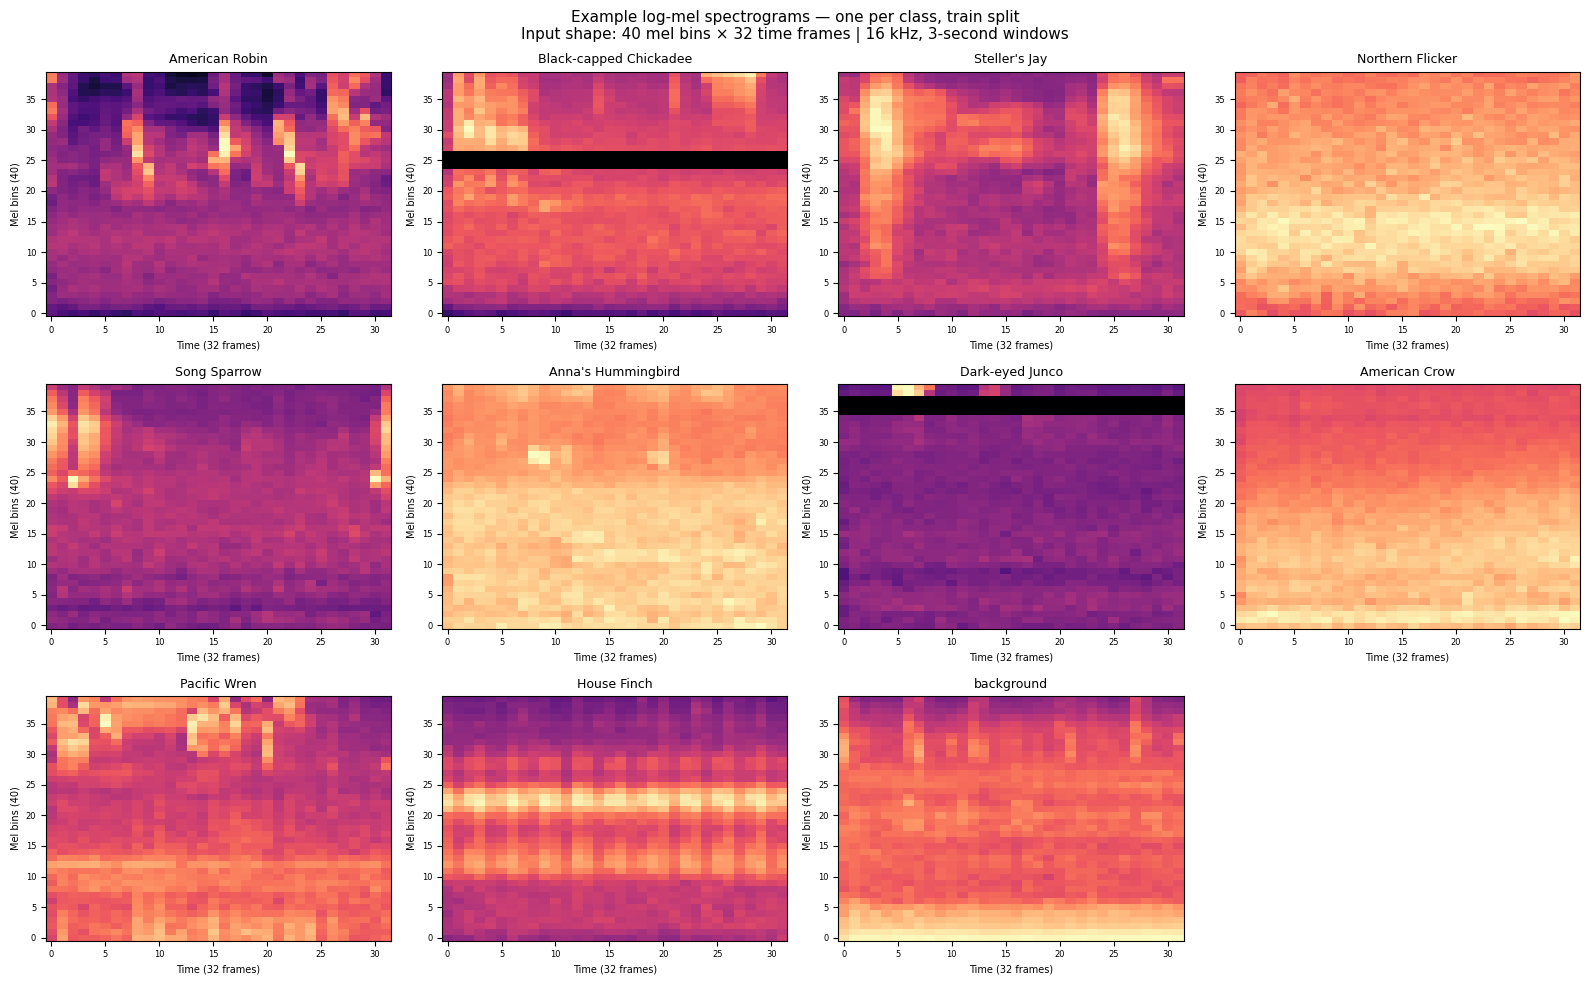

Saved /Users/aaravwadhwani/Desktop/EE446/Final Project/PocketBirdNET/data/example_spectrograms.png


In [10]:
# ── Example spectrogram plots — one per class from the train set ──────────────
X_tr = train_d["X"]
y_tr = train_d["y"]

fig, axes = plt.subplots(3, 4, figsize=(16, 10))
axes = axes.flatten()

for cls_idx, name in enumerate(SPECIES):
    ax = axes[cls_idx]
    mask = y_tr == cls_idx
    if not mask.any():
        ax.set_title(f"{name}\n(no samples)")
        ax.axis("off")
        continue
    img = X_tr[mask][0][:, :, 0]   # (40, 32)
    ax.imshow(img, origin="lower", aspect="auto", cmap="magma", vmin=0, vmax=1)
    ax.set_title(name, fontsize=9)
    ax.set_xlabel("Time (32 frames)", fontsize=7)
    ax.set_ylabel("Mel bins (40)", fontsize=7)
    ax.tick_params(labelsize=6)

axes[-1].axis("off")  # 11 classes in a 3×4 grid — hide the 12th cell

plt.suptitle(
    "Example log-mel spectrograms — one per class, train split\n"
    "Input shape: 40 mel bins × 32 time frames | 16 kHz, 3-second windows",
    fontsize=11,
)
plt.tight_layout()
out_png = DATA_DIR / "example_spectrograms.png"
plt.savefig(out_png, dpi=120, bbox_inches="tight")
plt.show()
print(f"Saved {out_png}")

In [11]:
# ── Final summary ─────────────────────────────────────────────────────────────
print("=" * 62)
print("DATA PIPELINE COMPLETE")
print("=" * 62)
print(f"  train.npz  : {len(train_d['X']):6d} windows  (includes augmented copies)")
print(f"  val.npz    : {len(val_d['X']):6d} windows")
print(f"  test.npz   : {len(test_d['X']):6d} windows")
print(f"  metadata.csv written — recording-level split auditable")
print()
print("Next: notebooks/02_teacher.ipynb — cache BirdNET soft targets for variant C.")
print("(Skip if only training variants A / B / D.)")

DATA PIPELINE COMPLETE
  train.npz  : 104294 windows  (includes augmented copies)
  val.npz    :  11284 windows
  test.npz   :  11596 windows
  metadata.csv written — recording-level split auditable

Next: notebooks/02_teacher.ipynb — cache BirdNET soft targets for variant C.
(Skip if only training variants A / B / D.)
